# 1️⃣ Setup & Dependencies

### Install advanced libraries for geospatial and ML tasks.
`folium`: For interactive maps.

`xgboost`: For predictive modeling.

`plotly`: For interactive charts.

In [1]:
# Install dependencies
!pip install contextily folium seaborn scikit-learn xgboost shap plotly matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 37.6 MB/s eta 0:00:00:00:0100:01


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import folium
from folium.plugins import MarkerCluster, HeatMap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("✅ Libraries Loaded Successfully")

✅ Libraries Loaded Successfully


# 2️⃣ Load & Preprocess Data
## Load the dataset and perform type casting.


In [3]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/global-ev-charging-station-network-2010-2026/global_ev_charging_station.csv


In [ ]:
# Get the dataset - https://www.kaggle.com/datasets/sohails07/global-ev-charging-station-network-2010-2026

file_path = "/kaggle/input/global-ev-charging-station-network-2010-2026/global_ev_charging_station.csv"

df = pd.read_csv(file_path, low_memory=False)

print(f"📊 Dataset Shape: {df.shape}")
df.head(3)

📊 Dataset Shape: (257585, 19)


,StationID,UUID,DataProviderID,Operator,UsageType,UsageCost,AddressTitle,AddressLine1,Town,StateOrProvince,Postcode,Country,Latitude,Longitude,MaxPowerKW,FastChargeCount,ConnectionTypes,StatusType,YearCreated
0,473101,5B1E6265-45A9-4D0E-83A7-AB49D84D0BB2,1,Tesla (including non-tesla),Public,NaN,Tesla Supercharger,Purley Way,NaN,NaN,NaN,United Kingdom,51.371709,-0.116955,250.0,1,CCS (Type 2),Operational,2026
1,472908,A5EA67A8-756B-4C09-B578-BAEC40AEA237,1,Lidl,Public - Membership Required,£0.57/kWh,Positive Energy - DoubleTree by Hilton Manches...,Outwood Road,Wythenshawe,England,M90 4HL,United Kingdom,53.366453,-2.269799,11.0,0,Type 2 (Socket Only),Operational,2026
2,472220,1CCABB37-2CE5-49D4-8DC0-5025BE976BA1,1,EZO (IE),Public - Membership Required,NaN,Holiday Inn Express,106 University Street,Belfast,NaN,BT7 1HP,United Kingdom,54.586836,-5.926869,50.0,1,CCS (Type 2),Operational,2025


# 3️⃣ Feature Engineering (Advanced)
1.  **`IsFastCharger`**: Boolean (True if Power > 50kW).

2.  **`CostCategory`**: Categorize `UsageCost` into Free, Paid, or Unknown.

3.  **`StationAge`**: Years since installation.

In [5]:
# 1. Fast Charging Flag
df["MaxPowerKW"] = pd.to_numeric(df["MaxPowerKW"], errors="coerce").fillna(0)
df["IsFastCharger"] = df["MaxPowerKW"] >= 50

# 2. Cost NLP
def categorize_cost(text):
    if pd.isna(text):
        return "Unknown"
    text = str(text).lower()
    if "free" in text or "0.00" in text:
        return "Free"
    return "Paid"


df["CostCategory"] = df["UsageCost"].apply(categorize_cost)

# 3. Station Age
current_year = 2026
df["YearCreated"] = pd.to_numeric(df["YearCreated"], errors="coerce")
df["StationAge"] = current_year - df["YearCreated"]

print("✅ Feature Engineering Complete")

✅ Feature Engineering Complete


# 4️⃣ The "Plug War": Connector Dominance by Region
## **CCS vs Tesla vs CHAdeMO vs Type 2**. 
### Who is winning in which country?

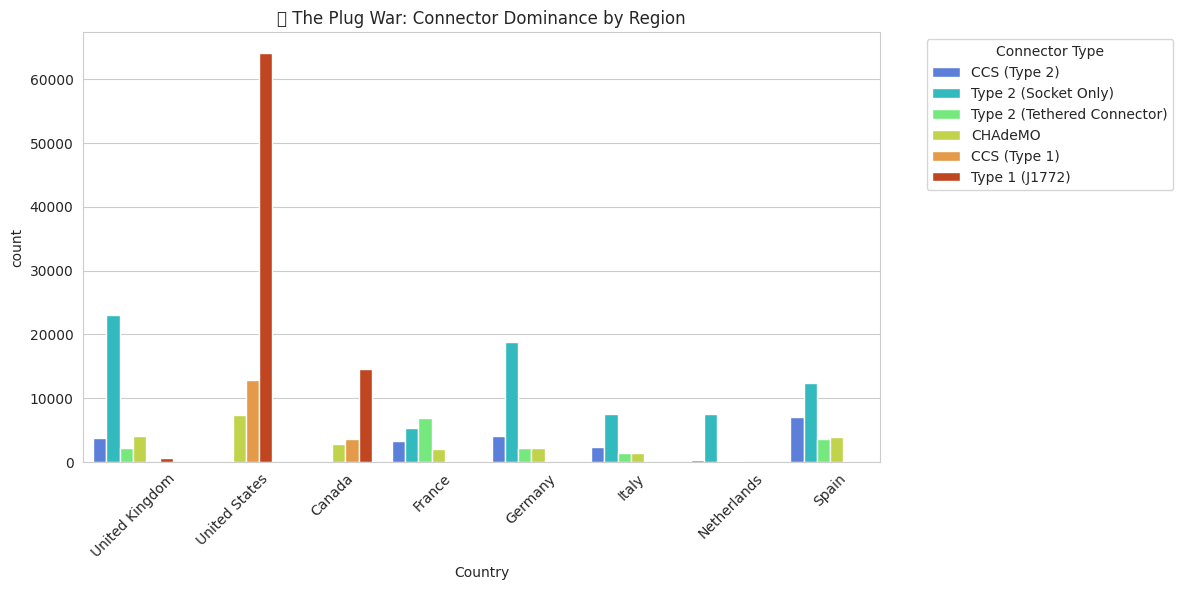

In [6]:
# Explode the ConnectionTypes column (comma-separated strings)
df_plugs = df.assign(Plug=df["ConnectionTypes"].str.split(", ")).explode("Plug")
df_plugs = df_plugs[df_plugs["Plug"].notna()]

# Filter for Top Plugs & Top Countries
top_plugs = df_plugs["Plug"].value_counts().nlargest(6).index
top_countries = df["Country"].value_counts().nlargest(8).index

plug_matrix = df_plugs[
    (df_plugs["Plug"].isin(top_plugs)) & (df_plugs["Country"].isin(top_countries))
]

plt.figure(figsize=(12, 6))
sns.countplot(data=plug_matrix, x="Country", hue="Plug", palette="turbo")
plt.title("🔌 The Plug War: Connector Dominance by Region")
plt.xticks(rotation=45)
plt.legend(title="Connector Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 5️⃣ Forecasting 2030: Growth Projection
### Using linear regression on historical counts to predict future station numbers.

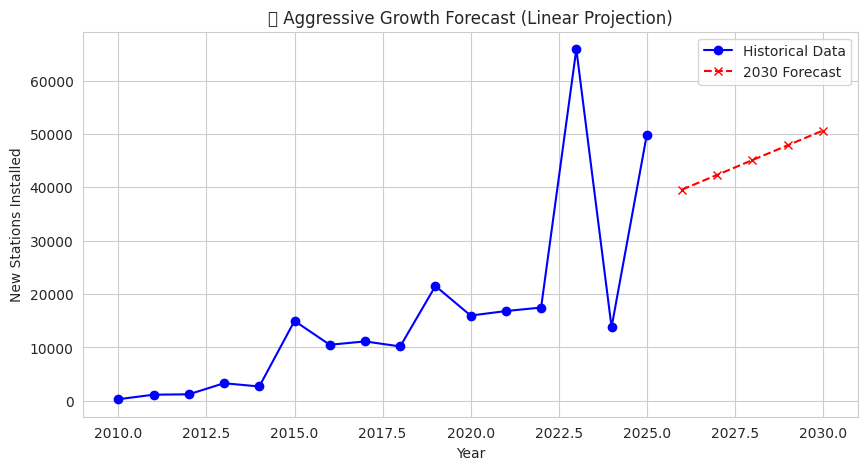

🔮 Predicted New Stations in 2030: 50,633


In [7]:
# Propagate counts
yearly_counts = df["YearCreated"].value_counts().sort_index()
yearly_counts = yearly_counts[
    (yearly_counts.index >= 2010) & (yearly_counts.index <= 2025)
]  # Filter clean years

X_year = yearly_counts.index.values.reshape(-1, 1)
y_count = yearly_counts.values

# Train simple trend model
reg = LinearRegression()
reg.fit(X_year, y_count)

# Predict 2026-2030
future_years = np.array([2026, 2027, 2028, 2029, 2030]).reshape(-1, 1)
future_preds = reg.predict(future_years)

plt.figure(figsize=(10, 5))
plt.plot(X_year, y_count, marker="o", label="Historical Data", color="blue")
plt.plot(
    future_years,
    future_preds,
    marker="x",
    linestyle="--",
    label="2030 Forecast",
    color="red",
)
plt.title("📈 Aggressive Growth Forecast (Linear Projection)")
plt.xlabel("Year")
plt.ylabel("New Stations Installed")
plt.legend()
plt.show()

print(f"🔮 Predicted New Stations in 2030: {int(future_preds[-1]):,}")

# 6️⃣ Interactive Map: Heatmap of Global Density
### Visualize the density of charging infrastructure significantly better than points.

In [8]:
# Sample 10,000 points to keep map responsive
map_data = df.dropna(subset=["Latitude", "Longitude"]).sample(min(10000, len(df)))

m = folium.Map(location=[20, 0], zoom_start=2, tiles="CartoDB dark_matter")

# Add Heatmap
heat_data = [[row["Latitude"], row["Longitude"]] for index, row in map_data.iterrows()]
HeatMap(heat_data, radius=10, blur=15).add_to(m)

# Save map (or display in notebook)
m.save("ev_density_map.html")
display(m)

# 7️⃣ Market Concentration (HHI Index)
*HHI < 1500*: Competitive Market

*HHI > 2500*: Monopoly Risk

In [9]:
def calculate_hhi(country_name):
    country_df = df[df["Country"] == country_name]
    shares = country_df["Operator"].value_counts(normalize=True) * 100
    hhi = (shares**2).sum()
    top_player = shares.index[0] if not shares.empty else "None"
    return hhi, top_player


focus_markets = ["United States", "United Kingdom", "France", "Germany", "Australia"]
print(f"{'Country':<15} | {'HHI':<6} | {'Status':<12} | {'Top Player'}")
print("-" * 60)
for country in focus_markets:
    hhi, top = calculate_hhi(country)
    status = "Competitive" if hhi < 1500 else "Monopoly" if hhi > 2500 else "Oligopoly"
    print(f"{country:<15} | {int(hhi):<6} | {status:<12} | {str(top)[:20]}")

Country         | HHI    | Status       | Top Player
------------------------------------------------------------
United States   | 2348   | Oligopoly    | ChargePoint
United Kingdom  | 856    | Competitive  | Shell Recharge Solut
France          | 597    | Competitive  | Izivia (Sodetrel)
Germany         | 833    | Competitive  | (Business Owner at L
Australia       | 1235   | Competitive  | Chargefox


# 8️⃣ ML: Predicting Station Failure (XGBoost)
### Predict `StatusType` (Operational vs Broken).


=== Reliability Prediction Model ===
              precision    recall  f1-score   support

           0       0.79      0.07      0.13      1787
           1       0.95      1.00      0.98     34763

    accuracy                           0.95     36550
   macro avg       0.87      0.53      0.55     36550
weighted avg       0.95      0.95      0.93     36550



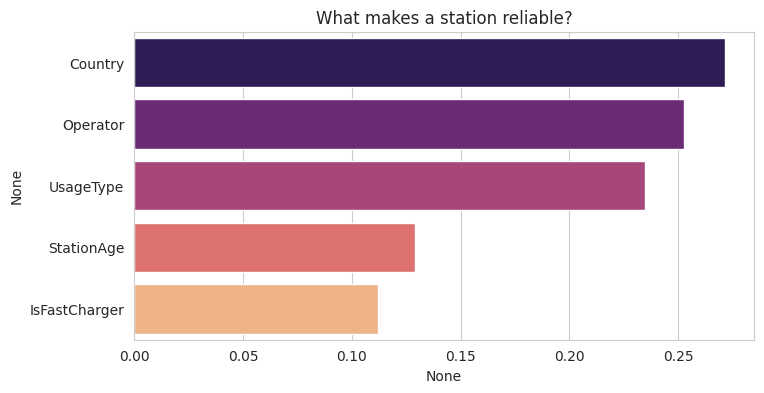

In [10]:
model_df = df[
    ["StatusType", "Operator", "UsageType", "Country", "IsFastCharger", "StationAge"]
].dropna()
model_df["Target"] = model_df["StatusType"].apply(
    lambda x: 1 if str(x).lower() == "operational" else 0
)

# Encode
for col in ["Operator", "UsageType", "Country"]:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))

# Train
X = model_df.drop(["StatusType", "Target"], axis=1)
y = model_df["Target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
model.fit(X_train, y_train)

# Results
print("\n=== Reliability Prediction Model ===")
print(classification_report(y_test, model.predict(X_test)))

# Feature Importance
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(
    ascending=False
)
plt.figure(figsize=(8, 4))
sns.barplot(x=feat_imp, y=feat_imp.index, palette="magma")
plt.title("What makes a station reliable?")
plt.show()


# 9️⃣ Conclusion
### 1.  **Forecast**: We predict continued aggressive growth through 2030.
### 2.  **Standards**: The Plug War chart clearly shows dominance of CCS in Europe vs Tesla in US.
### 3.  **Density**: The Heatmap reveals coverage gaps in central regions.